# Step 5: Inference

Using the fitted m2 (hierarchical) posterior to answer real questions.

1. **Designation-level PR rates** — what is the typical rate per designation?
2. **Developer ranking** — where does each developer sit relative to their peers?
3. **New developer prediction** — what rate should we expect from someone we have never observed?

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

DESIGNATIONS       = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']
MU_ORG             = np.log(8)
TRUE_DESIG_OFFSETS = np.array([-0.2, 0.3, 0.2, -0.3, -0.7])

df     = pd.read_csv('../../data/pr_simulated.csv')
dev_df = df.drop_duplicates('developer_id').sort_values('developer_id')

N_DEVS  = df['developer_id'].nunique()
N_TEAMS = df['team_id'].nunique()

dev_desig_labels = dev_df['designation'].values
dev_team_labels  = dev_df['team'].values

# Load saved posterior — run 04_fit_models.ipynb first if file not found
idata_m2 = az.from_netcdf('../../data/idata_m2.nc')
post     = idata_m2.posterior

print("Posterior loaded.")
print(f"Chains x draws: {post.sizes['chain']} x {post.sizes['draw']}")

Posterior loaded.
Chains x draws: 4 x 1000


## 1. Designation-Level PR Rates

The designation offset `delta[d]` captures how much faster/slower a designation
is relative to the grand mean. On the probability scale: `exp(mu_org + delta[d])`.

This answers: **"What is the expected monthly PR rate for a typical developer of this designation?"**
(marginalising over team and individual variation)

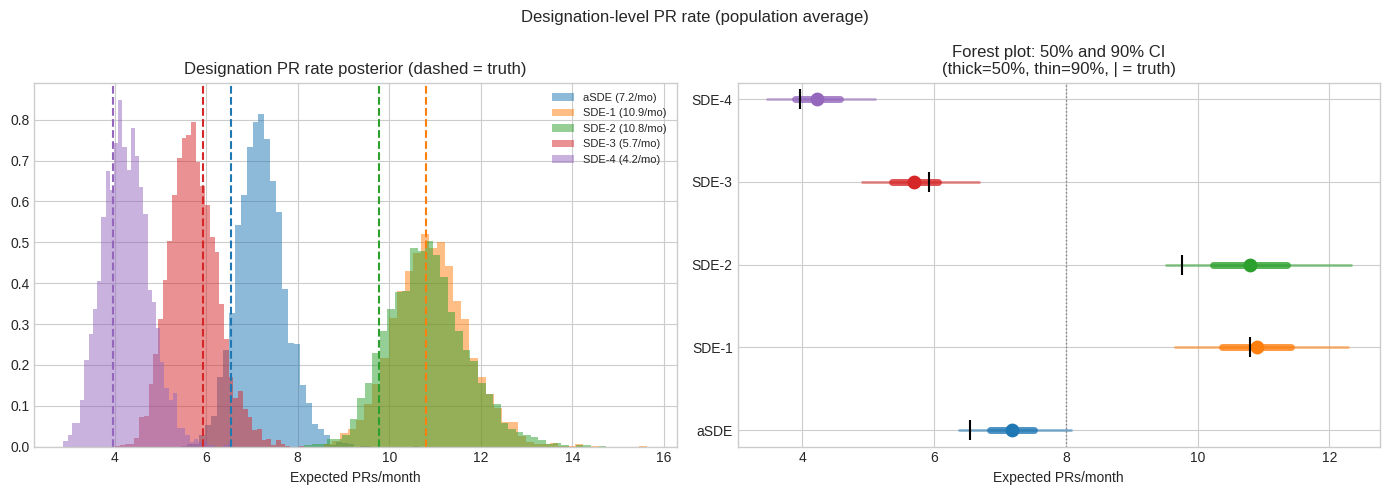

Designation rate summary:
  aSDE    : median=7.2  90%CI=[6.4,8.1]  truth=6.5
  SDE-1   : median=10.9  90%CI=[9.7,12.3]  truth=10.8
  SDE-2   : median=10.8  90%CI=[9.5,12.3]  truth=9.8
  SDE-3   : median=5.7  90%CI=[4.9,6.7]  truth=5.9
  SDE-4   : median=4.2  90%CI=[3.5,5.1]  truth=4.0


In [2]:
mu_org_s = post['mu_org'].values.flatten()                          # (S,)
delta_s  = post['delta'].values.reshape(-1, len(DESIGNATIONS))     # (S, 5)

# Expected rate per designation (no team/dev noise — population-level)
lam_desig = np.exp(mu_org_s[:, None] + delta_s)                    # (S, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Posterior distributions
ax = axes[0]
for i, desig in enumerate(DESIGNATIONS):
    vals = lam_desig[:, i]
    lo, hi = np.percentile(vals, [5, 95])
    ax.hist(vals, bins=40, alpha=0.5, color=f'C{i}',
            label=f"{desig} ({np.median(vals):.1f}/mo)", density=True)
    ax.axvline(np.exp(MU_ORG + TRUE_DESIG_OFFSETS[i]),
               color=f'C{i}', linestyle='--', lw=1.5)
ax.set_xlabel("Expected PRs/month")
ax.set_title("Designation PR rate posterior (dashed = truth)")
ax.legend(fontsize=8)

# Panel 2: Forest plot
ax = axes[1]
for i, desig in enumerate(DESIGNATIONS):
    vals = lam_desig[:, i]
    med  = np.median(vals)
    lo50, hi50 = np.percentile(vals, [25, 75])
    lo90, hi90 = np.percentile(vals, [5, 95])
    ax.plot([lo90, hi90], [i, i], color=f'C{i}', lw=2, alpha=0.5)
    ax.plot([lo50, hi50], [i, i], color=f'C{i}', lw=5, alpha=0.8)
    ax.scatter(med, i, color=f'C{i}', s=80, zorder=5)
    ax.scatter(np.exp(MU_ORG + TRUE_DESIG_OFFSETS[i]), i,
               marker='|', s=200, color='black', zorder=6)

ax.set_yticks(range(len(DESIGNATIONS)))
ax.set_yticklabels(DESIGNATIONS)
ax.set_xlabel("Expected PRs/month")
ax.set_title("Forest plot: 50% and 90% CI\n(thick=50%, thin=90%, | = truth)")
ax.axvline(np.exp(MU_ORG), color='gray', lw=1, linestyle=':')

plt.suptitle("Designation-level PR rate (population average)", fontsize=12)
plt.tight_layout()
plt.show()

print("Designation rate summary:")
for i, desig in enumerate(DESIGNATIONS):
    vals = lam_desig[:, i]
    lo, hi = np.percentile(vals, [5, 95])
    print(f"  {desig:<8}: median={np.median(vals):.1f}  "
          f"90%CI=[{lo:.1f},{hi:.1f}]  truth={np.exp(MU_ORG+TRUE_DESIG_OFFSETS[i]):.1f}")

## 2. Developer Ranking

For each developer we have a full posterior distribution over their monthly rate.
We rank by posterior median and show 90% credible intervals.

This answers: **"Who are the top/bottom developers, and how certain are we?"**

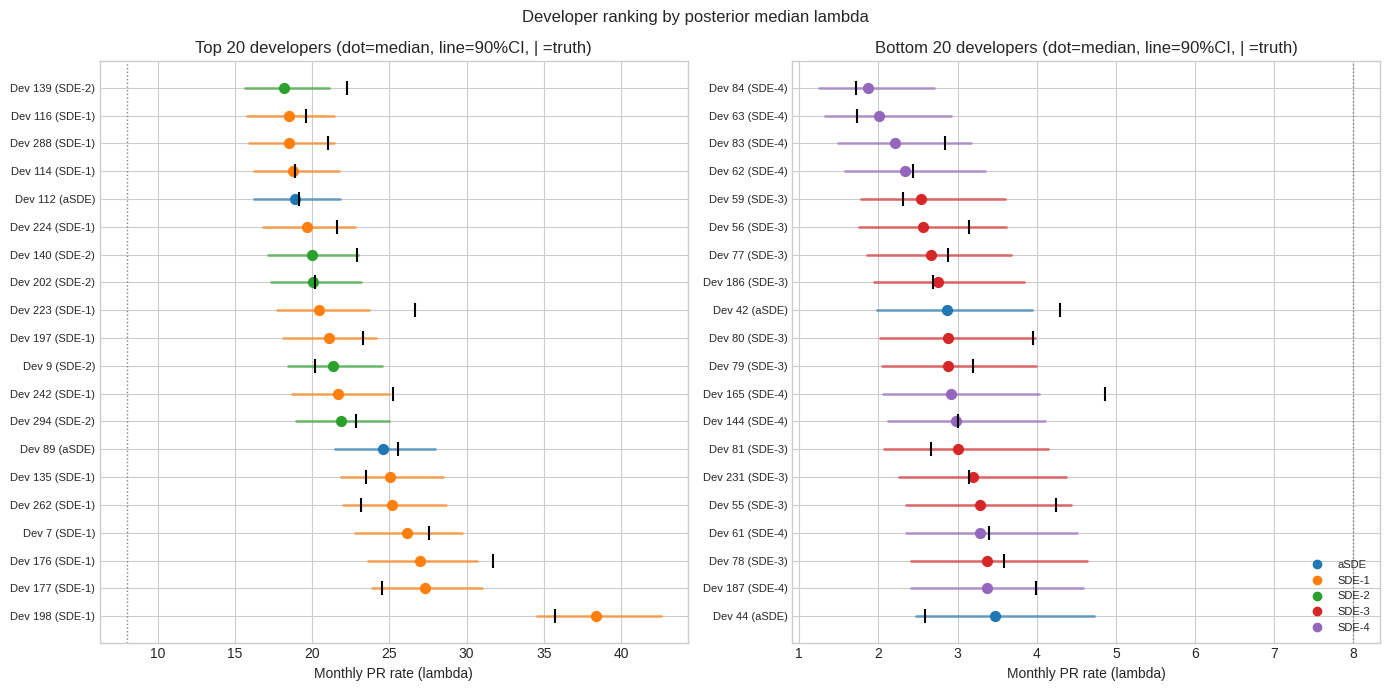

In [2]:
alpha_s  = post['alpha'].values.reshape(-1, N_DEVS)   # (S, N_DEVS)
lam_s    = np.exp(alpha_s)                             # (S, N_DEVS)

lam_med  = np.median(lam_s, axis=0)
lam_lo   = np.percentile(lam_s, 5,  axis=0)
lam_hi   = np.percentile(lam_s, 95, axis=0)

rank_order = np.argsort(lam_med)[::-1]   # highest first

# Show top 20 and bottom 20
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (label, idxs) in zip(axes, [
    ("Top 20 developers",    rank_order[:20]),
    ("Bottom 20 developers", rank_order[-20:]),
]):
    for j, dev_idx in enumerate(idxs):
        med = lam_med[dev_idx]
        lo  = lam_lo[dev_idx]
        hi  = lam_hi[dev_idx]
        desig_i = DESIGNATIONS.index(dev_desig_labels[dev_idx])
        color   = f'C{desig_i}'
        ax.plot([lo, hi], [j, j], color=color, lw=2, alpha=0.6)
        ax.scatter(med, j, color=color, s=50, zorder=5)
        ax.scatter(dev_df['true_lam'].iloc[dev_idx], j,
                   marker='|', color='black', s=100, zorder=6)

    ax.set_yticks(range(len(idxs)))
    ax.set_yticklabels(
        [f"Dev {idxs[j]} ({dev_desig_labels[idxs[j]]})" for j in range(len(idxs))],
        fontsize=8)
    ax.set_xlabel("Monthly PR rate (lambda)")
    ax.set_title(label + " (dot=median, line=90%CI, | =truth)")
    ax.axvline(np.exp(MU_ORG), color='gray', lw=1, linestyle=':')

# Legend for designations
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], marker='o', color=f'C{i}', label=d, linestyle='None')
           for i, d in enumerate(DESIGNATIONS)]
axes[1].legend(handles=handles, fontsize=8, loc='lower right')

plt.suptitle("Developer ranking by posterior median lambda", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Ranking Uncertainty

A developer ranked #5 by posterior median might actually be #2 or #10.
We can quantify this by looking at the **rank distribution** for each developer.

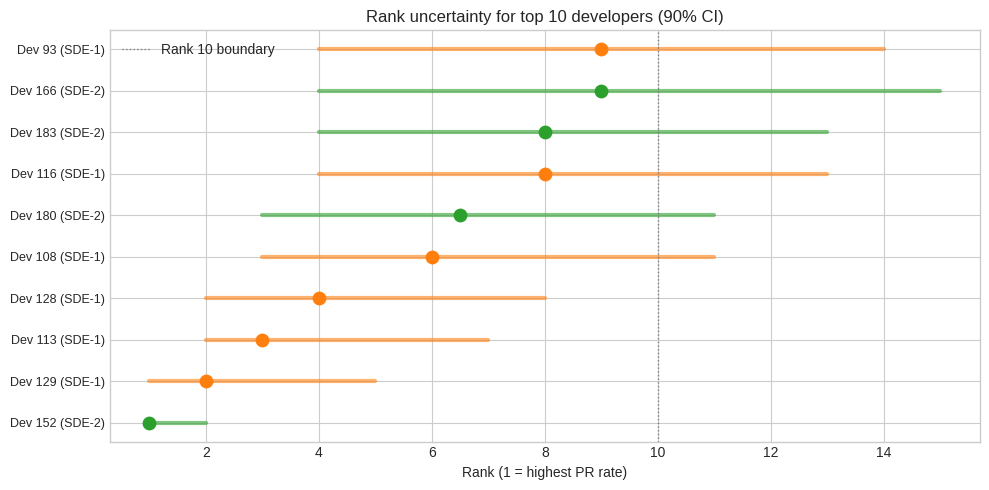

Top 10 by median rank:
  Dev 152  (SDE-2   ): median rank=1  90%CI=[1,2]
  Dev 129  (SDE-1   ): median rank=2  90%CI=[1,5]
  Dev 113  (SDE-1   ): median rank=3  90%CI=[2,7]
  Dev 128  (SDE-1   ): median rank=4  90%CI=[2,8]
  Dev 108  (SDE-1   ): median rank=6  90%CI=[3,11]
  Dev 180  (SDE-2   ): median rank=6  90%CI=[3,11]
  Dev 116  (SDE-1   ): median rank=8  90%CI=[4,13]
  Dev 183  (SDE-2   ): median rank=8  90%CI=[4,13]
  Dev 166  (SDE-2   ): median rank=9  90%CI=[4,15]
  Dev 93   (SDE-1   ): median rank=9  90%CI=[4,14]


In [6]:
# Compute rank for each sample (rank 1 = highest rate)
ranks_s = np.argsort(np.argsort(-lam_s, axis=1), axis=1) + 1  # (S, N_DEVS)

# Show rank uncertainty for top 10 developers (by median rank)
median_rank = np.median(ranks_s, axis=0)
top10_idx   = np.argsort(median_rank)[:10]

fig, ax = plt.subplots(figsize=(10, 5))

for j, dev_idx in enumerate(top10_idx):
    ranks = ranks_s[:, dev_idx]
    lo, hi = np.percentile(ranks, [5, 95])
    med    = np.median(ranks)
    desig_i = DESIGNATIONS.index(dev_desig_labels[dev_idx])
    ax.plot([lo, hi], [j, j], color=f'C{desig_i}', lw=3, alpha=0.6)
    ax.scatter(med, j, color=f'C{desig_i}', s=80, zorder=5)

ax.set_yticks(range(10))
ax.set_yticklabels(
    [f"Dev {top10_idx[j]} ({dev_desig_labels[top10_idx[j]]})" for j in range(10)],
    fontsize=9)
ax.set_xlabel("Rank (1 = highest PR rate)")
ax.set_title("Rank uncertainty for top 10 developers (90% CI)")
ax.axvline(10, color='gray', lw=1, linestyle=':', label='Rank 10 boundary')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 10 by median rank:")
for j, dev_idx in enumerate(top10_idx):
    lo, hi = np.percentile(ranks_s[:, dev_idx], [5, 95])
    print(f"  Dev {dev_idx:<4} ({dev_desig_labels[dev_idx]:<8}): "
          f"median rank={np.median(ranks_s[:,dev_idx]):.0f}  "
          f"90%CI=[{lo:.0f},{hi:.0f}]")

## 4. New Developer Prediction

A brand new developer joins. We know their designation and team but have **no observations**.

We predict their rate by:
1. Using the posterior for `mu_org`, `delta[desig]`, `gamma[team]`
2. Sampling fresh developer noise: `z_new ~ Normal(0,1)` scaled by posterior `sigma_dev`

This gives wider intervals than for observed developers — honest about the unknown individual.

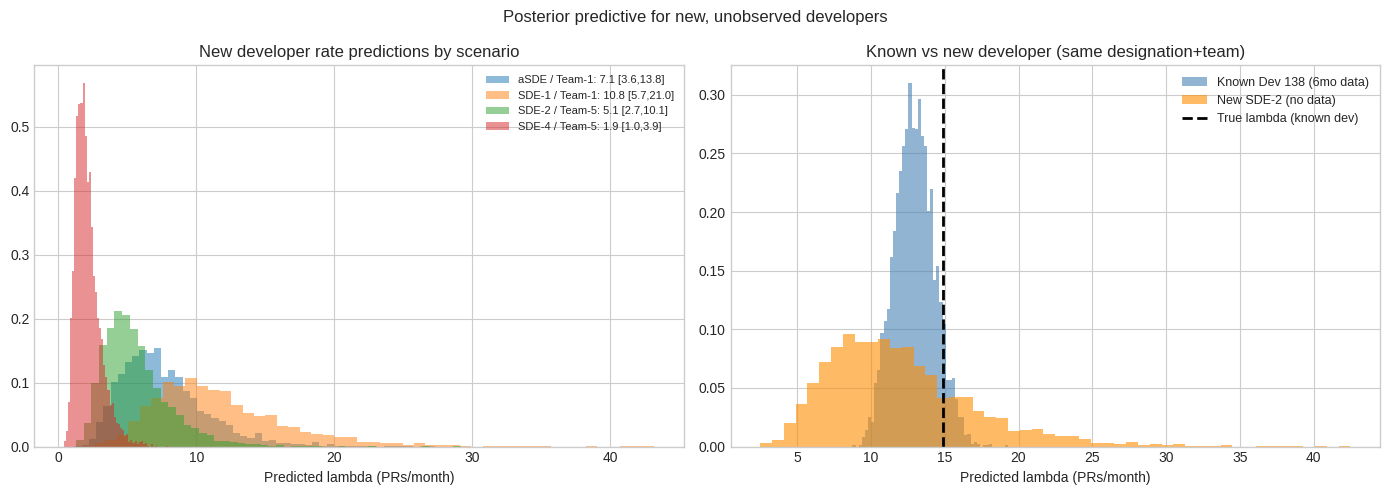

New developer predictions:
  aSDE     / Team-1  : median=7.2  90%CI=[3.7,13.8]
  SDE-1    / Team-1  : median=11.0  90%CI=[5.6,21.4]
  SDE-2    / Team-5  : median=5.2  90%CI=[2.7,10.1]
  SDE-4    / Team-5  : median=1.9  90%CI=[1.0,3.9]


In [7]:
sigma_dev_s = post['sigma_dev'].values.flatten()          # (S,)
gamma_s     = post['gamma'].values.reshape(-1, N_TEAMS)   # (S, 10)

rng = np.random.default_rng(42)

def predict_new_developer(desig_name, team_name, n_samples=None):
    desig_idx = DESIGNATIONS.index(desig_name)
    team_idx  = int(team_name.split('-')[1]) - 1
    S = len(mu_org_s) if n_samples is None else n_samples

    z_new    = rng.normal(0, 1, S)
    log_lam  = (mu_org_s[:S]
                + delta_s[:S, desig_idx]
                + gamma_s[:S, team_idx]
                + z_new * sigma_dev_s[:S])
    return np.exp(log_lam)

# Compare predictions for different designation + team combos
scenarios = [
    ('aSDE',  'Team-1'),
    ('SDE-1', 'Team-1'),
    ('SDE-2', 'Team-5'),
    ('SDE-4', 'Team-5'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for desig, team in scenarios:
    lam_new = predict_new_developer(desig, team)
    lo, hi  = np.percentile(lam_new, [5, 95])
    med     = np.median(lam_new)
    label   = f"{desig} / {team}: {med:.1f} [{lo:.1f},{hi:.1f}]"
    ax.hist(lam_new, bins=50, alpha=0.5, density=True, label=label)

ax.set_xlabel("Predicted lambda (PRs/month)")
ax.set_title("New developer rate predictions by scenario")
ax.legend(fontsize=8)

# Panel 2: Compare new dev vs known dev in same role
ax = axes[1]
# Pick a known SDE-2 developer
sde2_devs = np.where(dev_desig_labels == 'SDE-2')[0][:1]
known_dev_idx = sde2_devs[0]
known_lam = lam_s[:, known_dev_idx]
new_lam   = predict_new_developer('SDE-2', dev_team_labels[known_dev_idx])

ax.hist(known_lam, bins=50, alpha=0.6, color='steelblue',
        density=True, label=f"Known Dev {known_dev_idx} (6mo data)")
ax.hist(new_lam,   bins=50, alpha=0.6, color='darkorange',
        density=True, label="New SDE-2 (no data)")
ax.axvline(dev_df['true_lam'].iloc[known_dev_idx],
           color='black', lw=2, linestyle='--', label='True lambda (known dev)')
ax.set_xlabel("Predicted lambda (PRs/month)")
ax.set_title("Known vs new developer (same designation+team)")
ax.legend(fontsize=9)

plt.suptitle("Posterior predictive for new, unobserved developers", fontsize=12)
plt.tight_layout()
plt.show()

print("New developer predictions:")
for desig, team in scenarios:
    lam_new = predict_new_developer(desig, team)
    lo, hi  = np.percentile(lam_new, [5, 95])
    print(f"  {desig:<8} / {team:<8}: median={np.median(lam_new):.1f}  90%CI=[{lo:.1f},{hi:.1f}]")

## 5. Developer Percentile Within Designation

Given a specific developer, we answer:

1. **Mean-based**: where does their posterior mean sit in the designation's population distribution? Simple point estimate percentile.
2. **Distribution-based**: `P(λ_dev > λ_random_SDE1)` — if we picked a random SDE-1, what is the probability this developer outperforms them? Accounts for uncertainty in both.

The difference matters:
- Mean-based ignores uncertainty in the developer's own estimate
- Distribution-based is honest — a developer with only 1 month of data has a wide posterior, so the comparison is uncertain even if their observed rate looks high

In [8]:
# ── Set developer of interest ─────────────────────────────────────────
DEV_ID = 198

# ── Get developer's designation ───────────────────────────────────────
dev_desig  = dev_desig_labels[DEV_ID]
desig_idx  = DESIGNATIONS.index(dev_desig)

print(f"Developer {DEV_ID}: {dev_desig} in {dev_team_labels[DEV_ID]}")
print(f"True lambda (ground truth): {dev_df['true_lam'].iloc[DEV_ID]:.2f} PRs/month")

# ── Posterior samples ─────────────────────────────────────────────────
alpha_s     = post['alpha'].values.reshape(-1, N_DEVS)
mu_org_s    = post['mu_org'].values.flatten()
delta_s     = post['delta'].values.reshape(-1, len(DESIGNATIONS))
sigma_dev_s = post['sigma_dev'].values.flatten()

S = len(mu_org_s)
rng_inf = np.random.default_rng(42)

# Dev 155 posterior lambda: shape (S,)
lam_dev = np.exp(alpha_s[:, DEV_ID])

# SDE-1 population mean (no individual noise): shape (S,)
lam_desig_mean = np.exp(mu_org_s + delta_s[:, desig_idx])

# Random SDE-1 peer (with individual noise): shape (S,)
z_peer   = rng_inf.normal(0, 1, S)
lam_peer = np.exp(mu_org_s + delta_s[:, desig_idx] + z_peer * sigma_dev_s)

# ── Method 1: Mean-based percentile ───────────────────────────────────
dev_mean       = lam_dev.mean()
pct_mean_based = (lam_desig_mean < dev_mean).mean() * 100

# ── Method 2: Distribution-based probabilities ────────────────────────
prob_beats_mean = (lam_dev > lam_desig_mean).mean() * 100
prob_beats_peer = (lam_dev > lam_peer).mean() * 100

# ── Percentile with uncertainty (95% CI) ──────────────────────────────
# For each posterior sample of lam_dev, compute what percentile it sits
# in the designation population distribution
# pct_samples[s] = fraction of designation samples below lam_dev[s]
pct_samples = (lam_desig_mean[:, None] < lam_dev[None, :]).mean(axis=0) * 100
pct_median  = np.median(pct_samples)
pct_lo      = np.percentile(pct_samples, 2.5)
pct_hi      = np.percentile(pct_samples, 97.5)

print(f"\n{'='*52}")
print(f"PERCENTILE ANALYSIS — Developer {DEV_ID} ({dev_desig})")
print(f"{'='*52}")
print(f"\nDev {DEV_ID} posterior lambda:")
print(f"  Mean   : {lam_dev.mean():.2f}")
print(f"  Median : {np.median(lam_dev):.2f}")
print(f"  95% CI : [{np.percentile(lam_dev,2.5):.2f}, {np.percentile(lam_dev,97.5):.2f}]")
print(f"\nMethod 1 — Mean-based (point estimate):")
print(f"  Dev {DEV_ID} posterior mean ({dev_mean:.2f}) is at the")
print(f"  {pct_mean_based:.1f}th percentile of {dev_desig} population")
print(f"\nMethod 2 — Distribution-based:")
print(f"  P(dev {DEV_ID} > typical {dev_desig})     = {prob_beats_mean:.1f}%")
print(f"  P(dev {DEV_ID} > random {dev_desig} peer) = {prob_beats_peer:.1f}%")
print(f"\nPercentile with uncertainty (95% CI):")
print(f"  Median percentile : {pct_median:.1f}th")
print(f"  95% CI            : [{pct_lo:.1f}, {pct_hi:.1f}]")
print(f"\nOutlier check:")
print(f"  Bottom 10%: {'YES' if pct_hi < 10 else 'POSSIBLY' if pct_lo < 10 else 'NO'} (95% CI upper = {pct_hi:.1f})")
print(f"  Bottom 25%: {'YES' if pct_hi < 25 else 'POSSIBLY' if pct_lo < 25 else 'NO'} (95% CI upper = {pct_hi:.1f})")

Developer 198: SDE-1 in Team-10
True lambda (ground truth): 35.75 PRs/month

PERCENTILE ANALYSIS — Developer 198 (SDE-1)

Dev 198 posterior lambda:
  Mean   : 38.48
  Median : 38.47
  95% CI : [33.83, 43.45]

Method 1 — Mean-based (point estimate):
  Dev 198 posterior mean (38.48) is at the
  100.0th percentile of SDE-1 population

Method 2 — Distribution-based:
  P(dev 198 > typical SDE-1)     = 100.0%
  P(dev 198 > random SDE-1 peer) = 99.9%

Percentile with uncertainty (95% CI):
  Median percentile : 100.0th
  95% CI            : [100.0, 100.0]

Outlier check:
  Bottom 10%: NO (95% CI upper = 100.0)
  Bottom 25%: NO (95% CI upper = 100.0)


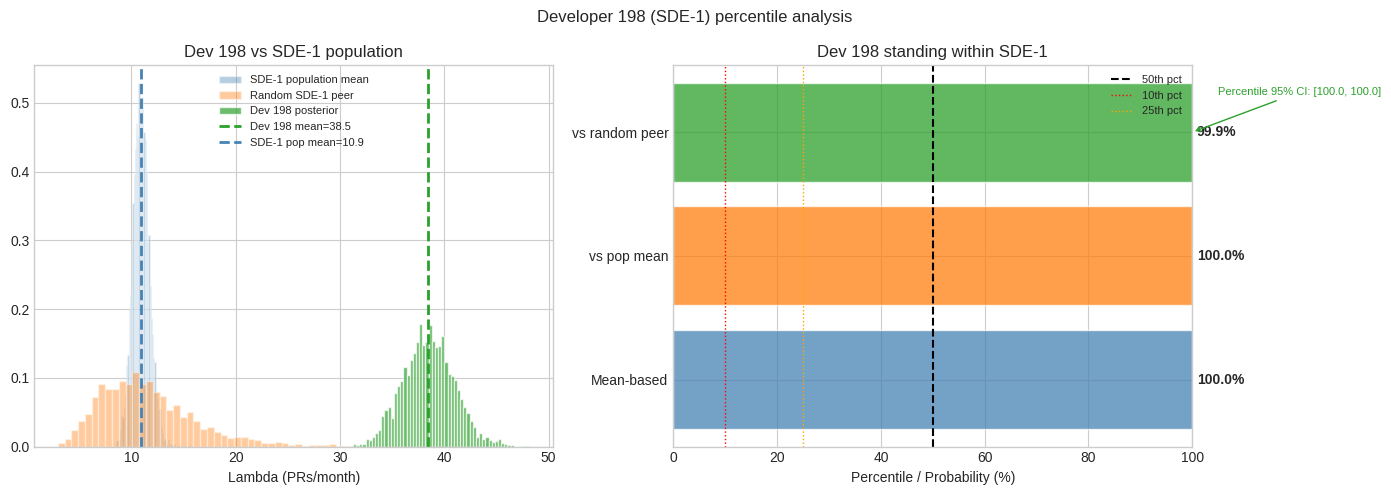

Summary: Dev 198 is at the 100.0th percentile of SDE-1s
95% CI [100.0, 100.0] — confidence in this ranking


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Overlaid distributions ───────────────────────────────────
ax = axes[0]
ax.hist(lam_desig_mean, bins=60, density=True, alpha=0.4,
        color='steelblue', label=f'{dev_desig} population mean', edgecolor='white')
ax.hist(lam_peer, bins=60, density=True, alpha=0.4,
        color='C1', label=f'Random {dev_desig} peer', edgecolor='white')
ax.hist(lam_dev,  bins=60, density=True, alpha=0.7,
        color='C2', label=f'Dev {DEV_ID} posterior', edgecolor='white')
ax.axvline(lam_dev.mean(), color='C2', lw=2, linestyle='--',
           label=f'Dev {DEV_ID} mean={lam_dev.mean():.1f}')
ax.axvline(lam_desig_mean.mean(), color='steelblue', lw=2, linestyle='--',
           label=f'{dev_desig} pop mean={lam_desig_mean.mean():.1f}')
ax.set_xlabel("Lambda (PRs/month)")
ax.set_title(f"Dev {DEV_ID} vs {dev_desig} population")
ax.legend(fontsize=8)

# ── Panel 2: Percentile summary with CI ───────────────────────────────
ax = axes[1]
methods = ['Mean-based', 'vs pop mean', 'vs random peer']
probs   = [pct_mean_based, prob_beats_mean, prob_beats_peer]
colors  = ['steelblue', 'C1', 'C2']

bars = ax.barh(methods, probs, color=colors, alpha=0.75, edgecolor='white')
ax.axvline(50,  color='black', lw=1.5, linestyle='--', label='50th pct')
ax.axvline(10,  color='red',   lw=1,   linestyle=':',  label='10th pct')
ax.axvline(25,  color='orange',lw=1,   linestyle=':',  label='25th pct')

for bar, prob in zip(bars, probs):
    ax.text(prob + 1, bar.get_y() + bar.get_height()/2,
            f'{prob:.1f}%', va='center', fontsize=10, fontweight='bold')

# Add percentile CI annotation
ax.annotate(f"Percentile 95% CI: [{pct_lo:.1f}, {pct_hi:.1f}]",
            xy=(pct_median, 2), xytext=(pct_median + 5, 2.3),
            fontsize=8, color='C2',
            arrowprops=dict(arrowstyle='->', color='C2', lw=1))

ax.set_xlim(0, 100)
ax.set_xlabel("Percentile / Probability (%)")
ax.set_title(f"Dev {DEV_ID} standing within {dev_desig}")
ax.legend(fontsize=8)

plt.suptitle(f"Developer {DEV_ID} ({dev_desig}) percentile analysis", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Summary: Dev {DEV_ID} is at the {pct_median:.1f}th percentile of {dev_desig}s")
print(f"95% CI [{pct_lo:.1f}, {pct_hi:.1f}] — confidence in this ranking")

## Summary

### What we can now answer from the model

| Question | Answer |
|----------|--------|
| Typical rate for SDE-1? | Posterior median + 90% CI from `exp(mu_org + delta[SDE-1])` |
| Where does Dev-42 rank? | Posterior rank distribution — median rank with uncertainty |
| Expected rate for new SDE-2? | Sample fresh `z_dev`, propagate through hierarchy |
| Is Dev-10 truly better than Dev-20? | Compare `P(lambda_10 > lambda_20)` from posterior samples |

### Key insight: new vs known developers
- A **known developer** (6 months of data): narrow posterior — we have real evidence
- A **new developer** (no data): wide posterior — only group-level information available
- The hierarchy bridges the gap: new developers start with the designation+team prior, then posterior updates as data arrives

### TODO (fine-tuning for later)
- Fix m1 identifiability: sum-to-zero constraint on group intercepts
- Fix m2 divergences: raise `target_accept=0.95` or use `HalfNormal` on sigmas
- Add `P(dev_A > dev_B)` contrast computation
- Posterior predictive check against held-out data